In [3]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
os.getcwd()

'/scale/user/mtannaou/alternance'

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [229]:
import pandas as pd;import xarray as xr;import numpy as np;from matplotlib import pyplot as plt;import os;

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from src.IR_to_SAR.data_preparation.distribution_data_visualisation import plot_sar,plot_ir
csv_tcva_tcprimed_path = "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/TCVA_matched_with_SARGEO_tcprimed.csv"
anggrek_csv_path = "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/anggrek_coloc_sar_ir.csv"
tcva_tcprimed = pd.read_csv(csv_tcva_tcprimed_path)
anggrek_df = pd.read_csv(anggrek_csv_path)
len(tcva_tcprimed)

1444

In [6]:
irs, sars = [],[]
irs_test,sars_test = [],[]

for i,row in tcva_tcprimed[(tcva_tcprimed["split"]=="train") | (tcva_tcprimed["split"]=="val")][:].iterrows():
    ir_path  = row["sargeo_path"];sar_aeqd_path = row["sar_aeqd_path"]
    try : 
        ir = xr.open_dataset(ir_path)["IRWIN"][4,1001//2-256//2:1001//2+256//2,1001//2-256//2:1001//2+256//2]
        sar = xr.open_dataset(sar_aeqd_path)["owiWindSpeed"][301//2-256//2:301//2+256//2,301//2-256//2:301//2+256//2].values
    except:
        continue
    sars.append(sar)
    irs.append(ir)

#test
for i,row in tcva_tcprimed[tcva_tcprimed["split"]=="test"][:].iterrows():
    ir_path  = row["sargeo_path"];sar_aeqd_path = row["sar_aeqd_path"]
    try : 
        ir = xr.open_dataset(ir_path)["IRWIN"][4,1001//2-256//2:1001//2+256//2,1001//2-256//2:1001//2+256//2]
        sar = xr.open_dataset(sar_aeqd_path)["owiWindSpeed"][301//2-256//2:301//2+256//2,301//2-256//2:301//2+256//2].values
    except:
        continue
    sars_test.append(sar)
    irs_test.append(ir)


print("sar shape :",np.array(sars).shape,np.array(sars_test).shape)
print("IR shape  :",np.array( irs).shape,np.array( irs_test).shape)

sar shape : (875, 256, 256) (131, 256, 256)
IR shape  : (875, 256, 256) (131, 256, 256)


In [7]:
irs_anggrek,vmaxs_anggrek = [],[]
#Anggrek
for i,row in anggrek_df.iterrows():
    ir_path = row["ir_path"]
    ir = xr.open_dataset(ir_path)["IR"][0,501//2-256//2:501//2+256//2,501//2-256//2:501//2+256//2]
    irs_anggrek.append(ir)
    vmaxs_anggrek.append(row["wind_speed (m/s)"])


Text(0.5, 0.98, 'Examples of radial rings used for infrared feature extraction')

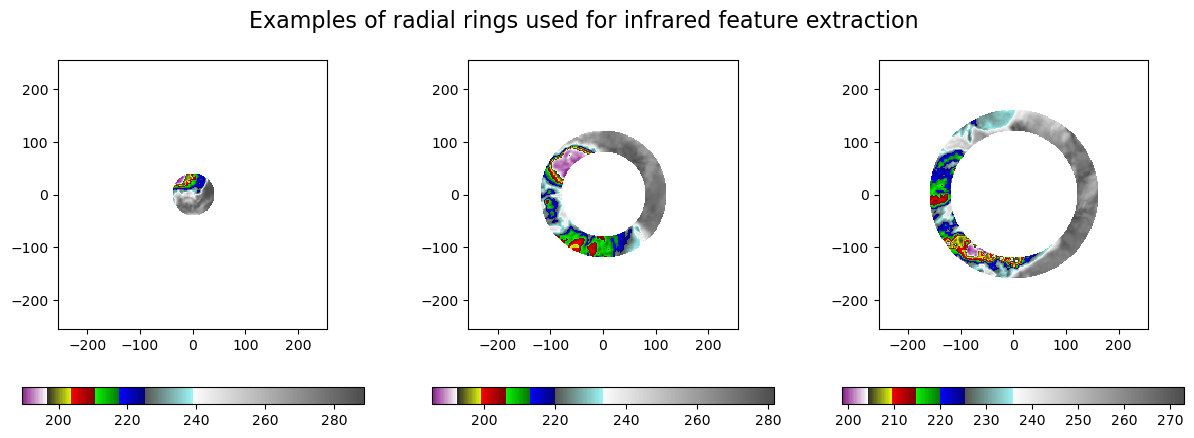

In [296]:
ring_pas = 2
N,H,W = np.array(irs).shape
ix,iy = np.indices((H,W),dtype=int)
cx,cy = W//2, H//2
radius = np.sqrt((ix-cx)**2 + (iy-cy)**2)
mask_ring_1 = (radius >= 0) & (radius < 10*ring_pas)
mask_ring_2 = (radius >= 10*ring_pas) & (radius < 20*ring_pas)
mask_ring_3 = (radius >= 20*ring_pas) & (radius < 30*ring_pas)
mask_ring_4 = (radius >= 30*ring_pas) & (radius < 40*ring_pas)
mask_ring_5 = (radius >= 40*ring_pas) & (radius < 50*ring_pas)
fig,axs = plt.subplots(1,3,figsize=(15,5))
plot_ir(irs[0].where(mask_ring_1).values,ax=axs[0],fig=fig,x_lim=256)
plot_ir(irs[0].where(mask_ring_3).values,ax=axs[1],fig=fig,x_lim=256)
plot_ir(irs[0].where(mask_ring_4).values,ax=axs[2],fig=fig,x_lim=256)
plt.suptitle("Examples of radial rings used for infrared feature extraction", fontsize=16)

In [9]:
rings_1=[];rings_2=[];rings_3=[];rings_4=[];rings_5=[]
rings_1_test=[];rings_2_test=[];rings_3_test=[];rings_4_test=[];rings_5_test=[]
rings_1_anggrek=[];rings_2_anggrek=[];rings_3_anggrek=[];rings_4_anggrek=[];rings_5_anggrek=[]
for i,ir in enumerate(irs):
    if np.isnan(ir).any():
        print("skip index",i)
        continue
    rings_1.append(ir.where(mask_ring_1).values.flatten())
    rings_2.append(ir.where(mask_ring_2).values.flatten())
    rings_3.append(ir.where(mask_ring_3).values.flatten())
    rings_4.append(ir.where(mask_ring_4).values.flatten())
    rings_5.append(ir.where(mask_ring_5).values.flatten())
#remove nan values
for i in range(len(rings_1)):
    rings_1[i] = rings_1[i][~np.isnan(rings_1[i])];rings_2[i] = rings_2[i][~np.isnan(rings_2[i])]
    rings_3[i] = rings_3[i][~np.isnan(rings_3[i])];rings_4[i] = rings_4[i][~np.isnan(rings_4[i])]
    rings_5[i] = rings_5[i][~np.isnan(rings_5[i])]

#test
for i,ir in enumerate(irs_test):
    if np.isnan(ir).any():
        print("skip index",i)
        continue
    rings_1_test.append(ir.where(mask_ring_1).values.flatten())
    rings_2_test.append(ir.where(mask_ring_2).values.flatten())
    rings_3_test.append(ir.where(mask_ring_3).values.flatten())
    rings_4_test.append(ir.where(mask_ring_4).values.flatten())
    rings_5_test.append(ir.where(mask_ring_5).values.flatten())
#remove nan values
for i in range(len(rings_1_test)):
    rings_1_test[i] = rings_1_test[i][~np.isnan(rings_1_test[i])];rings_2_test[i] = rings_2_test[i][~np.isnan(rings_2_test[i])]
    rings_3_test[i] = rings_3_test[i][~np.isnan(rings_3_test[i])];rings_4_test[i] = rings_4_test[i][~np.isnan(rings_4_test[i])]
    rings_5_test[i] = rings_5_test[i][~np.isnan(rings_5_test[i])]

#anggrek
for i,ir in enumerate(irs_anggrek):
    if np.isnan(ir).any():
        print("skip index",i)
        continue
    rings_1_anggrek.append(ir.where(mask_ring_1).values.flatten())
    rings_2_anggrek.append(ir.where(mask_ring_2).values.flatten())
    rings_3_anggrek.append(ir.where(mask_ring_3).values.flatten())
    rings_4_anggrek.append(ir.where(mask_ring_4).values.flatten())
    rings_5_anggrek.append(ir.where(mask_ring_5).values.flatten())
#remove nan values
for i in range(len(rings_1_anggrek)):
    rings_1_anggrek[i] = rings_1_anggrek[i][~np.isnan(rings_1_anggrek[i])];rings_2_anggrek[i] = rings_2_anggrek[i][~np.isnan(rings_2_anggrek[i])]
    rings_3_anggrek[i] = rings_3_anggrek[i][~np.isnan(rings_3_anggrek[i])];rings_4_anggrek[i] = rings_4_anggrek[i][~np.isnan(rings_4_anggrek[i])]
    rings_5_anggrek[i] = rings_5_anggrek[i][~np.isnan(rings_5_anggrek[i])]


skip index 258


In [10]:
stats_ir = []
stats_ir_test = []
stats_ir_anggrek =  []
for i in range(len(rings_1)):
    min_1 = np.nanmin(rings_1[i]); max_1= np.nanmax(rings_1[i]); mean_1 = np.nanmean(rings_1[i]); std_1 = np.nanstd(rings_1[i]); median_1 = np.nanmedian(rings_1[i])
    min_2 = np.nanmin(rings_2[i]); max_2= np.nanmax(rings_2[i]); mean_2 = np.nanmean(rings_2[i]); std_2 = np.nanstd(rings_2[i]); median_2 = np.nanmedian(rings_2[i])
    min_3 = np.nanmin(rings_3[i]); max_3= np.nanmax(rings_3[i]); mean_3 = np.nanmean(rings_3[i]); std_3 = np.nanstd(rings_3[i]); median_3 = np.nanmedian(rings_3[i])
    min_4 = np.nanmin(rings_4[i]); max_4= np.nanmax(rings_4[i]); mean_4 = np.nanmean(rings_4[i]); std_4 = np.nanstd(rings_4[i]); median_4 = np.nanmedian(rings_4[i])
    min_5 = np.nanmin(rings_5[i]); max_5= np.nanmax(rings_5[i]); mean_5 = np.nanmean(rings_5[i]); std_5 = np.nanstd(rings_5[i]); median_5 = np.nanmedian(rings_5[i])
    stats_ir.append([[min_1,max_1,mean_1,std_1,median_1],
                     [min_2,max_2,mean_2,std_2,median_2],
                     [min_3,max_3,mean_3,std_3,median_3],
                     [min_4,max_4,mean_4,std_4,median_4],
                     [min_5,max_5,mean_5,std_5,median_5]])

stats_ir = np.array(stats_ir)

#test
for i in range(len(rings_1_test)):
    min_1 = np.nanmin(rings_1_test[i]); max_1= np.nanmax(rings_1_test[i]); mean_1 = np.nanmean(rings_1_test[i]); std_1 = np.nanstd(rings_1_test[i]); median_1 = np.nanmedian(rings_1_test[i])
    min_2 = np.nanmin(rings_2_test[i]); max_2= np.nanmax(rings_2_test[i]); mean_2 = np.nanmean(rings_2_test[i]); std_2 = np.nanstd(rings_2_test[i]); median_2 = np.nanmedian(rings_2_test[i])
    min_3 = np.nanmin(rings_3_test[i]); max_3= np.nanmax(rings_3_test[i]); mean_3 = np.nanmean(rings_3_test[i]); std_3 = np.nanstd(rings_3_test[i]); median_3 = np.nanmedian(rings_3_test[i])
    min_4 = np.nanmin(rings_4_test[i]); max_4= np.nanmax(rings_4_test[i]); mean_4 = np.nanmean(rings_4_test[i]); std_4 = np.nanstd(rings_4_test[i]); median_4 = np.nanmedian(rings_4_test[i])
    min_5 = np.nanmin(rings_5_test[i]); max_5= np.nanmax(rings_5_test[i]); mean_5 = np.nanmean(rings_5_test[i]); std_5 = np.nanstd(rings_5_test[i]); median_5 = np.nanmedian(rings_5_test[i])
    stats_ir_test.append([[min_1,max_1,mean_1,std_1,median_1],
                     [min_2,max_2,mean_2,std_2,median_2],
                     [min_3,max_3,mean_3,std_3,median_3],
                     [min_4,max_4,mean_4,std_4,median_4],
                     [min_5,max_5,mean_5,std_5,median_5]])

stats_ir_test = np.array(stats_ir_test)

#anggrek
for i in range(len(rings_1_anggrek)):
    min_1 = np.nanmin(rings_1_anggrek[i]); max_1= np.nanmax(rings_1_anggrek[i]); mean_1 = np.nanmean(rings_1_anggrek[i]); std_1 = np.nanstd(rings_1_anggrek[i]); median_1 = np.nanmedian(rings_1_anggrek[i])
    min_2 = np.nanmin(rings_2_anggrek[i]); max_2= np.nanmax(rings_2_anggrek[i]); mean_2 = np.nanmean(rings_2_anggrek[i]); std_2 = np.nanstd(rings_2_anggrek[i]); median_2 = np.nanmedian(rings_2_anggrek[i])
    min_3 = np.nanmin(rings_3_anggrek[i]); max_3= np.nanmax(rings_3_anggrek[i]); mean_3 = np.nanmean(rings_3_anggrek[i]); std_3 = np.nanstd(rings_3_anggrek[i]); median_3 = np.nanmedian(rings_3_anggrek[i])
    min_4 = np.nanmin(rings_4_anggrek[i]); max_4= np.nanmax(rings_4_anggrek[i]); mean_4 = np.nanmean(rings_4_anggrek[i]); std_4 = np.nanstd(rings_4_anggrek[i]); median_4 = np.nanmedian(rings_4_anggrek[i])
    min_5 = np.nanmin(rings_5_anggrek[i]); max_5= np.nanmax(rings_5_anggrek[i]); mean_5 = np.nanmean(rings_5_anggrek[i]); std_5 = np.nanstd(rings_5_anggrek[i]); median_5 = np.nanmedian(rings_5_anggrek[i])
    stats_ir_anggrek.append([[min_1,max_1,mean_1,std_1,median_1],
                     [min_2,max_2,mean_2,std_2,median_2],
                     [min_3,max_3,mean_3,std_3,median_3],
                     [min_4,max_4,mean_4,std_4,median_4],
                     [min_5,max_5,mean_5,std_5,median_5]])

stats_ir_anggrek = np.array(stats_ir_anggrek)
stats_ir.shape,stats_ir_test.shape,stats_ir_anggrek.shape

((874, 5, 5), (131, 5, 5), (153, 5, 5))

In [11]:
vmaxs = []
vmaxs_test = []

for i,sar in enumerate(sars) : 
    if np.isnan(irs[i]).any():
        print("skip index",i)
        continue
    vmaxs.append(np.nanmax(sar))
    
vmaxs = np.array(vmaxs)

#test
for i,sar in enumerate(sars_test) : 
    if np.isnan(irs_test[i]).any():
        print("skip index",i)
        continue
    vmaxs_test.append(np.nanmax(sar))
    
vmaxs_test = np.array(vmaxs_test)
vmaxs_anggrek = np.array(vmaxs_anggrek)
print("Shape des vmax : ",vmaxs.shape,vmaxs_test.shape,vmaxs_anggrek.shape)

skip index 258
Shape des vmax :  (874,) (131,) (153,)


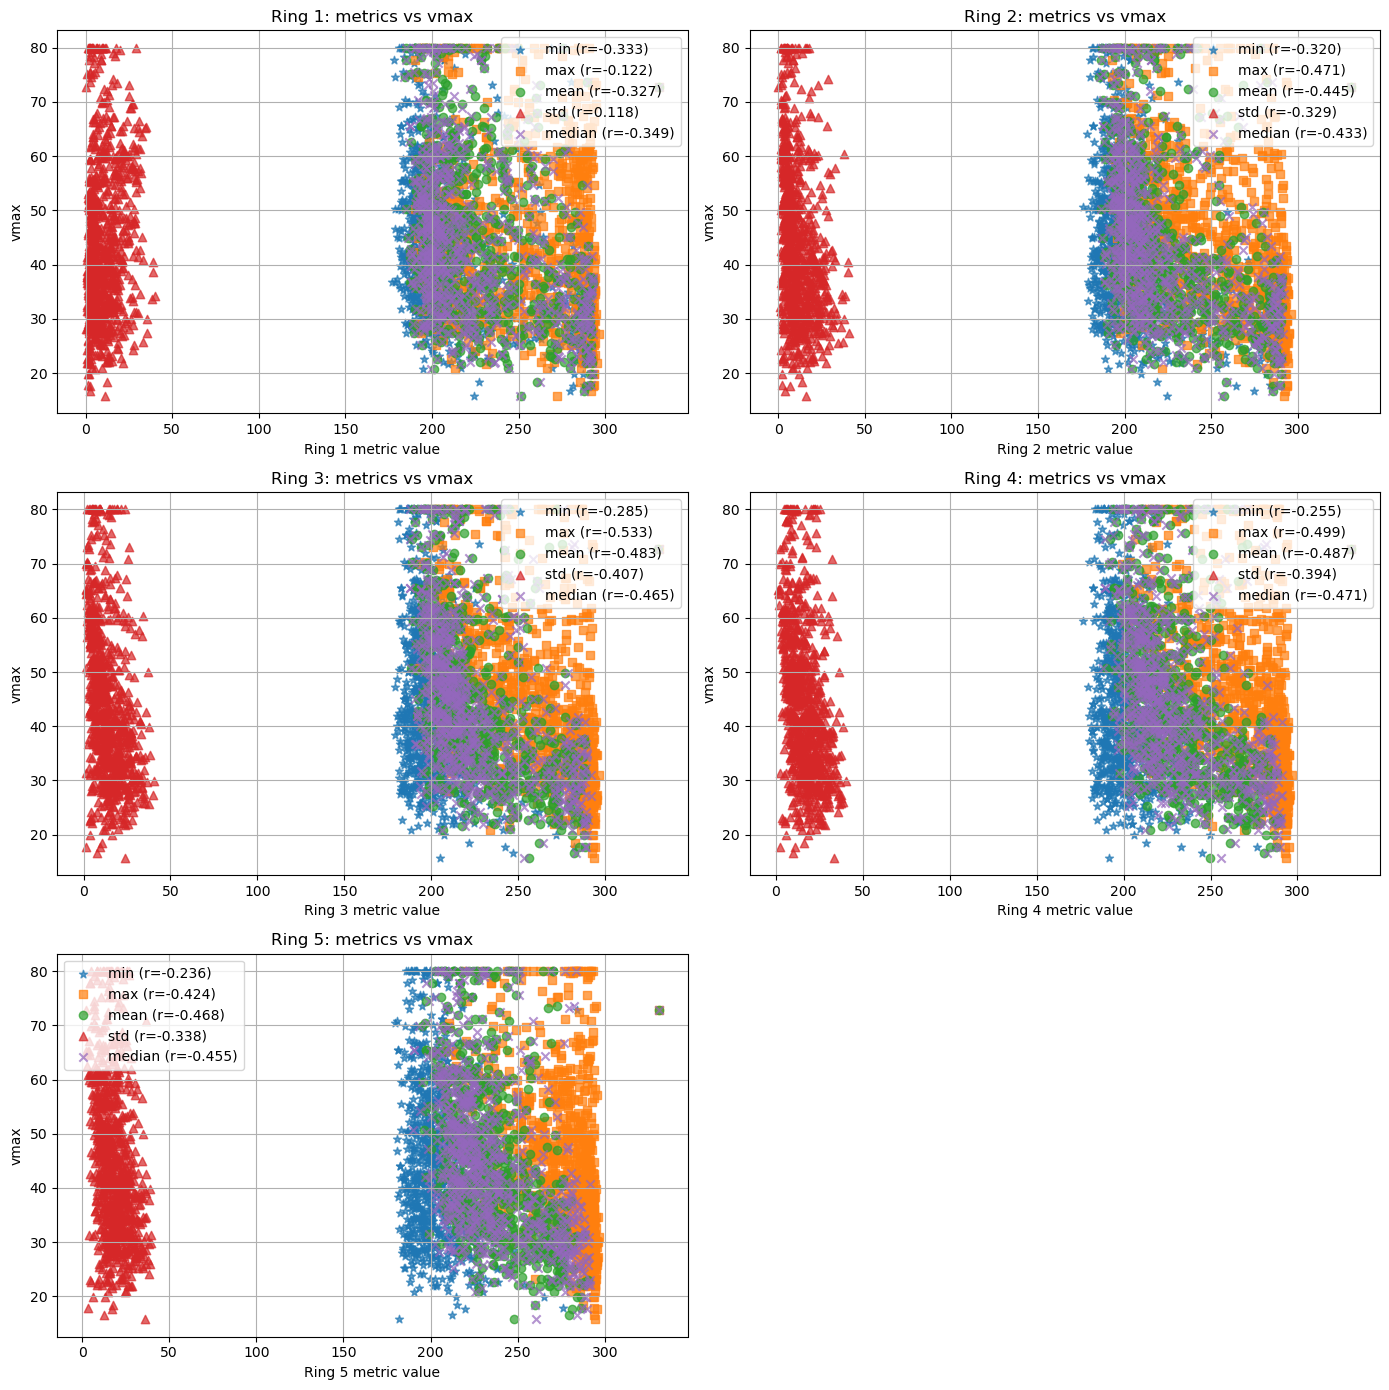

Text(0.5, 1.02, 'Correlation between ring-based infrared statistics and Vmax across radial bands')

<Figure size 640x480 with 0 Axes>

In [297]:
import matplotlib.pyplot as plt

metric_names = ["min", "max", "mean", "std", "median"]
markers = ["*", "s", "o", "^", "x"]   # star, square, circle, triangle, x


stats_ir_plot = stats_ir
assert stats_ir_plot.shape[0] == vmaxs.shape[0], "Mismatch: stats_ir vs vmaxs length!"

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ring_id in range(5):
    ax = axes[ring_id]

    for m in range(5):
        x = stats_ir_plot[:, ring_id, m]
        y = vmaxs

        r = np.corrcoef(x, y)[0, 1]
        ax.scatter(
            x, y,
            marker=markers[m],
            label=f"{metric_names[m]} (r={r:.3f})",
            alpha=0.7
        )

    ax.set_xlabel(f"Ring {ring_id+1} metric value")
    ax.set_ylabel("vmax")
    ax.set_title(f"Ring {ring_id+1}: metrics vs vmax")
    ax.grid(True)
    ax.legend()

# Hide unused subplot
axes[5].axis("off")

plt.tight_layout()
plt.show()
plt.suptitle(
    "Correlation between ring-based infrared statistics and Vmax across radial bands",
    fontsize=16,
    y=1.02
)


In [24]:
X = stats_ir.reshape(stats_ir.shape[0], -1)  
X_test = stats_ir_test.reshape(stats_ir_test.shape[0], -1)  
X_anggrek = stats_ir_anggrek.reshape(stats_ir_anggrek.shape[0], -1)  
y = vmaxs.reshape(-1, 1)
y_test = vmaxs_test.reshape(-1, 1)
y_anggrek = vmaxs_anggrek.reshape(-1, 1)
print("X shape:", X.shape, "y shape:", y.shape)
print("X_ets shape:", X_test.shape, "y_test shape:", y_test.shape)
print("X_anggrek shape:", X_anggrek.shape, "y_anggrek shape:", y_anggrek.shape)

X shape: (874, 25) y shape: (874, 1)
X_ets shape: (131, 25) y_test shape: (131, 1)
X_anggrek shape: (153, 25) y_anggrek shape: (153, 1)


In [25]:
X_train, X_test, y_train, y_test = X,X_test,y,y_test
scaler_X = StandardScaler()
scaler_y = StandardScaler()
pca = PCA(n_components=0.95,whiten=True)

X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)
X_anggrek_s = scaler_X.transform(X_anggrek)

y_train_s = scaler_y.fit_transform(y_train).ravel() 
y_test_s  = scaler_y.transform(y_test).ravel()
y_anggrek_s = scaler_y.transform(y_anggrek).ravel()

In [46]:
mlp = MLPRegressor(
    hidden_layer_sizes=(16, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=1e-3,
    max_iter=2000,
    random_state=0,
    early_stopping=True,
    n_iter_no_change=50,
    validation_fraction=0.2
)
mlp.fit(X_train_s, y_train_s)

,loss,'squared_error'
,hidden_layer_sizes,"(16, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True


=== Test metrics (original vmax scale) ===
MAE  : 9.125 m/s
RMSE : 12.292 m/s
R^2  : 0.329 m/s


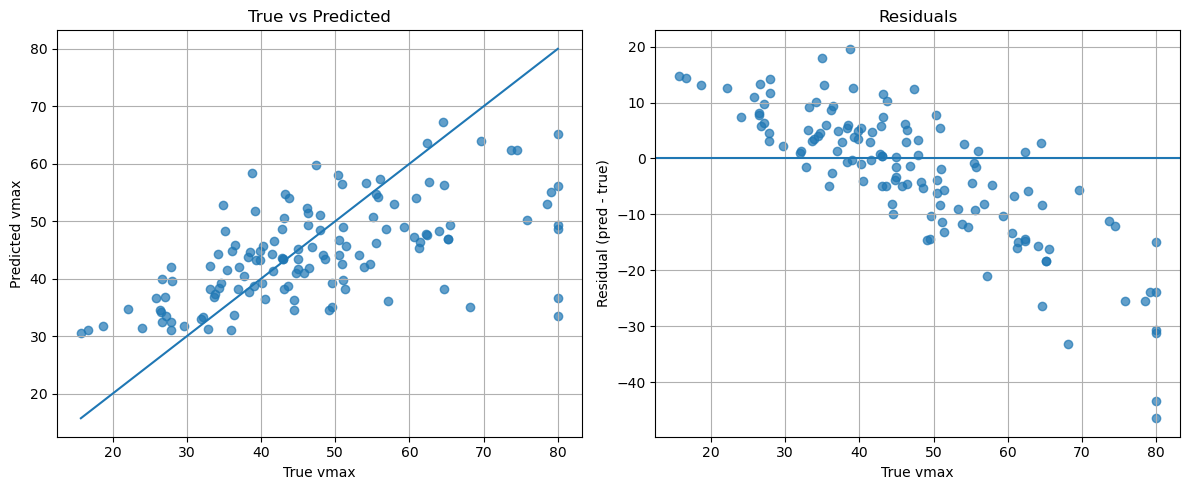

In [47]:
y_pred_test_s = mlp.predict(X_test_s)
y_pred_anggrek_s = mlp.predict(X_anggrek_s)
y_pred_test = scaler_y.inverse_transform(y_pred_test_s.reshape(-1, 1)).ravel()
y_pred_anggrek  = scaler_y.inverse_transform(y_pred_anggrek_s.reshape(-1, 1)).ravel()
y_test_orig = y_test.ravel()

mae = mean_absolute_error(y_test_orig, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_test))
r2 = r2_score(y_test_orig, y_pred_test)

print("=== Test metrics (original vmax scale) ===")
print(f"MAE  : {mae:.3f} m/s")
print(f"RMSE : {rmse:.3f} m/s")
print(f"R^2  : {r2:.3f} m/s")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_orig, y_pred_test, alpha=0.7)

minv = min(y_test_orig.min(), y_pred_test.min())
maxv = max(y_test_orig.max(), y_pred_test.max())
axes[0].plot([minv, maxv], [minv, maxv])  # y = x line

axes[0].set_xlabel("True vmax")
axes[0].set_ylabel("Predicted vmax")
axes[0].set_title("True vs Predicted")
axes[0].grid(True)


res = y_pred_test - y_test_orig
axes[1].scatter(y_test_orig, res, alpha=0.7)
axes[1].axhline(0)

axes[1].set_xlabel("True vmax")
axes[1].set_ylabel("Residual (pred - true)")
axes[1].set_title("Residuals")
axes[1].grid(True)

plt.tight_layout()
plt.show()


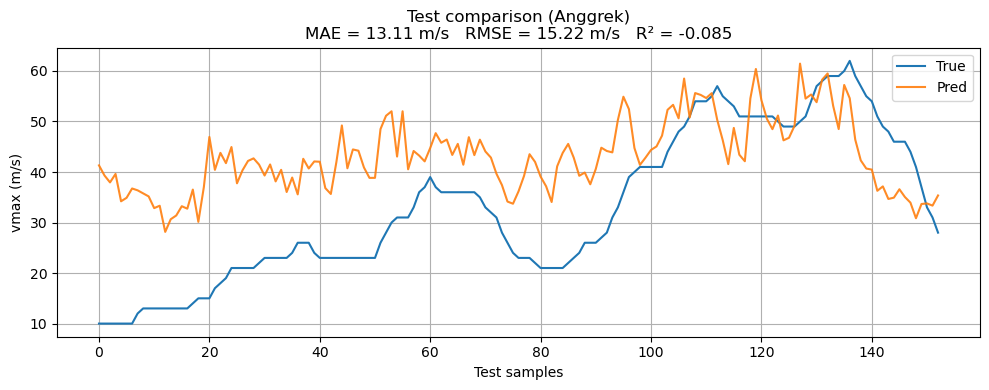

In [48]:
y_pred_ang_s = mlp.predict(X_anggrek_s)
y_pred_ang   = scaler_y.inverse_transform(y_pred_ang_s.reshape(-1, 1)).ravel()

mae = mean_absolute_error(y_anggrek, y_pred_ang)
rmse = np.sqrt(mean_squared_error(y_anggrek, y_pred_ang))
r2 = r2_score(y_anggrek, y_pred_ang)

plt.figure(figsize=(10, 4))
plt.plot(y_anggrek, label="True")
plt.plot(y_pred_ang, label="Pred", alpha=0.9)

plt.title(
    f"Test comparison (Anggrek)\n"
    f"MAE = {mae:.2f} m/s   RMSE = {rmse:.2f} m/s   R² = {r2:.3f}"
)
plt.xlabel("Test samples")
plt.ylabel("vmax (m/s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

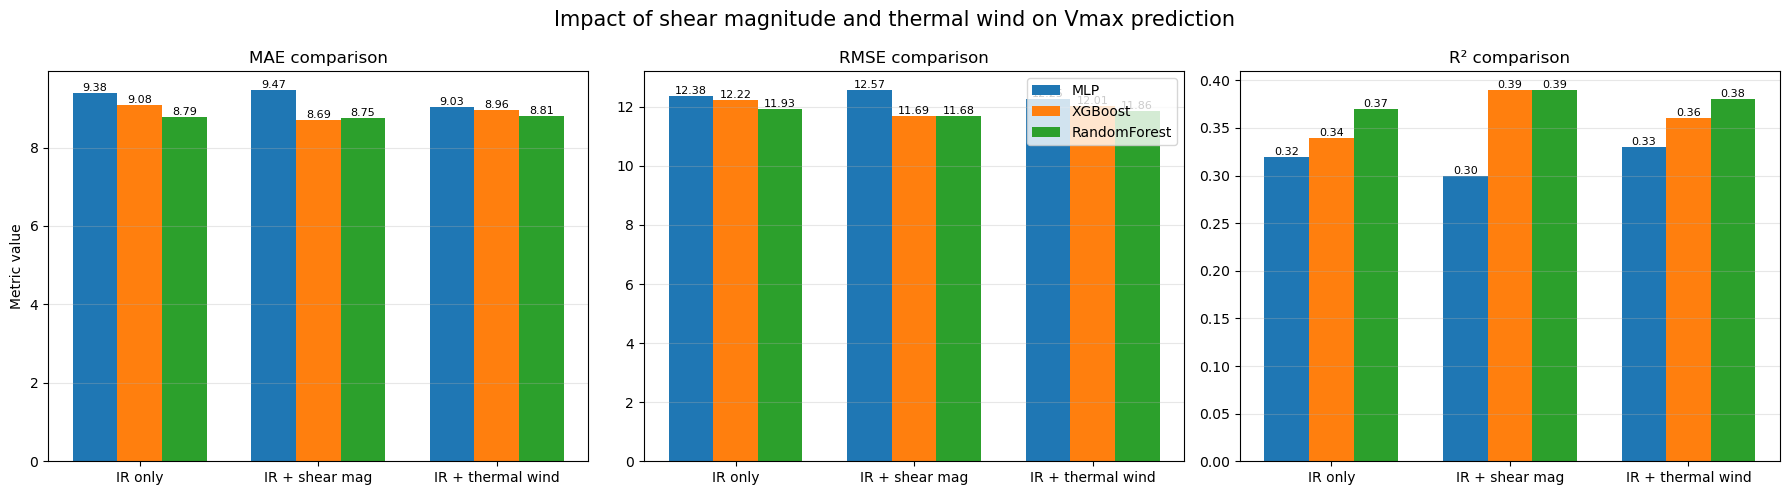

In [327]:
import numpy as np
import matplotlib.pyplot as plt

cases = ["IR only", "IR + shear mag", "IR + thermal wind"]

# ===== Metrics =====
mae = {
    "MLP": [9.38, 9.47, 9.03],
    "XGB": [9.08, 8.69, 8.96],
    "RF":  [8.79, 8.75, 8.81],
}

rmse = {
    "MLP": [12.38, 12.57, 12.25],
    "XGB": [12.22, 11.69, 12.01],
    "RF":  [11.93, 11.68, 11.86],
}

r2 = {
    "MLP": [0.32, 0.30, 0.33],
    "XGB": [0.34, 0.39, 0.36],
    "RF":  [0.37, 0.39, 0.38],
}

metrics_data = [mae, rmse, r2]
titles = ["MAE comparison", "RMSE comparison", "R² comparison"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

width = 0.25
x = np.arange(len(cases))

for ax, data, title in zip(axes, metrics_data, titles):

    bars1 = ax.bar(x - width, data["MLP"], width, label="MLP")
    bars2 = ax.bar(x, data["XGB"], width, label="XGBoost")
    bars3 = ax.bar(x + width, data["RF"], width, label="RandomForest")

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(cases)
    ax.grid(axis="y", alpha=0.3)

    # values above bars
    for bars in [bars1, bars2, bars3]:
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width()/2,
                h,
                f"{h:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

axes[0].set_ylabel("Metric value")
axes[1].legend(loc="upper right")

plt.suptitle(
    "Impact of shear magnitude and thermal wind on Vmax prediction",
    fontsize=15
)

plt.tight_layout()
plt.show()


## L'ajout du Shear 



In [130]:
shear_mag,shear_dir =[], []
shear_mag_test,shear_dir_test = [], []
cyclons_phase_space_thermal_wind,cyclons_phase_space_thermal_wind_test = [], []
shear_mag_columns = [f"shear_magnitude_{j}" for j in range(1, 9)]
shear_dir_columns = [f"shear_direction_{j}" for j in range(1, 9)]
cyclons_phase_space_thermal_wind_columns = [f"cyclone_phase_space_thermal_wind_{i}" for i in range(1,3)]
for i,row in tcva_tcprimed[(tcva_tcprimed["split"]=="train") | (tcva_tcprimed["split"]=="val")].iterrows():
    ir_path = row["sargeo_path"];sar_aeqd_path = row["sar_aeqd_path"]
    try:
        ir = xr.open_dataset(ir_path)["IRWIN"][4,1001//2-256//2:1001//2+256//2,1001//2-256//2:1001//2+256//2]
        sar = xr.open_dataset(sar_aeqd_path)["owiWindSpeed"][301//2-256//2:301//2+256//2,301//2-256//2:301//2+256//2].values
        if np.isnan(ir).any():
            print("skipped index :",i)
            continue
    except:
        continue
    
    shear_mag.append(row[shear_mag_columns].values)
    shear_dir.append(row[shear_dir_columns].values)
    cyclons_phase_space_thermal_wind.append(row[cyclons_phase_space_thermal_wind_columns].values)

shear_mag=np.array(shear_mag)
shear_dir = np.array(shear_dir)
cyclons_phase_space_thermal_wind = np.array(cyclons_phase_space_thermal_wind)

#test shear
for i,row in tcva_tcprimed[tcva_tcprimed["split"]=="test"].iterrows():
    ir_path = row["sargeo_path"];sar_aeqd_path = row["sar_aeqd_path"]
    try:
        ir = xr.open_dataset(ir_path)["IRWIN"][4,1001//2-256//2:1001//2+256//2,1001//2-256//2:1001//2+256//2]
        sar = xr.open_dataset(sar_aeqd_path)["owiWindSpeed"][301//2-256//2:301//2+256//2,301//2-256//2:301//2+256//2].values
        if np.isnan(ir).any():
            print("skipped index :",i)
            continue
    except:
        continue
    
    shear_mag_test.append(row[shear_mag_columns].values)
    shear_dir_test.append(row[shear_dir_columns].values)
    cyclons_phase_space_thermal_wind_test.append(row[cyclons_phase_space_thermal_wind_columns].values)

shear_mag_test = np.array(shear_mag_test)
shear_dir_test = np.array(shear_dir_test)
cyclons_phase_space_thermal_wind_test = np.array(cyclons_phase_space_thermal_wind_test)
print("shear magnitude shape",shear_mag.shape,"- shear direction shape :",shear_dir.shape)
print("shear magnitude test shape",shear_mag_test.shape,"- shear direction test shape :",shear_dir_test.shape)

skipped index : 405
shear magnitude shape (874, 8) - shear direction shape : (874, 8)
shear magnitude test shape (131, 8) - shear direction test shape : (131, 8)


In [338]:
ds = xr.open_dataset("/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v00r00/cyclobs/al132025/IRWIN/s1c-ew-owi-cm-20251026t111125-20251026t111229-000003-009592_ll_gd_GEO-IRWIN.nc")
irwin = ds["IRWIN"]
ds["time"].values

array(['2025-10-26T09:15:07.000000000', '2025-10-26T09:45:07.000000000',
       '2025-10-26T10:15:07.000000000', '2025-10-26T10:45:07.000000000',
       '2025-10-26T11:15:07.000000000', '2025-10-26T11:45:07.000000000',
       '2025-10-26T12:15:07.000000000', '2025-10-26T12:45:07.000000000',
       '2025-10-26T13:15:07.000000000'], dtype='datetime64[ns]')

In [324]:
shear = np.concatenate([cyclons_phase_space_thermal_wind],axis=1)   
#cyclons_phase_space_thermal_wind,shear_dir,shear_mag
shear_test = np.concatenate([cyclons_phase_space_thermal_wind_test],axis=1)
#cyclons_phase_space_thermal_wind_test,shear_dir_test,shear_mag
# pca_shear = PCA(n_components=0.95,whiten=True)
# shear = pca_shear.fit_transform(shear)
# shear_test = pca_shear.transform(shear_test)
print(shear.shape)

X_train_with_shear = np.concatenate(
    [X_train,shear],
    axis=1
)

X_test_with_shear = np.concatenate(
    [X_test,shear_test],
    axis=1
)

scaler_with_shear = StandardScaler()
X_train_with_shear_s = scaler_with_shear.fit_transform(X_train_with_shear)
X_test_with_shear_s  = scaler_with_shear.transform(X_test_with_shear)

(874, 2)


In [325]:
print("start mlp training : ------------------------------------------------")
mlp_with_shear = MLPRegressor(
    hidden_layer_sizes=(16, 16, 64, 64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=1e-3,
    max_iter=2000,
    random_state=0,
    early_stopping=True,
    n_iter_no_change=100,
    validation_fraction=0.2
)
mlp_with_shear.fit(X_train_with_shear_s, y_train_s)

print("start xgboost training : --------------------------------------------")
xgb_with_shear = XGBRegressor(
    n_estimators=100,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=1,
    objective="reg:squarederror",
    random_state=0,
    n_jobs=-1
)

xgb_with_shear.fit(X_train_with_shear, y_train)
print("start random forest training : --------------------------------------")
rf_with_shear = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=0,
    n_jobs=-1
)

rf_with_shear.fit(X_train_with_shear, y_train)

start mlp training : ------------------------------------------------
start xgboost training : --------------------------------------------
start random forest training : --------------------------------------


,n_estimators,1000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Test metrics :
MLP        -> MAE: 9.02538253393192 RMSE: 12.250841579334116 R2: 0.3331631612805446
XGBoost    -> MAE: 8.964223168464102 RMSE: 12.00651754094847 R2: 0.359495986234577
RandomForest -> MAE: 8.808711913974236 RMSE: 11.858846071868081 R2: 0.37515456666171376


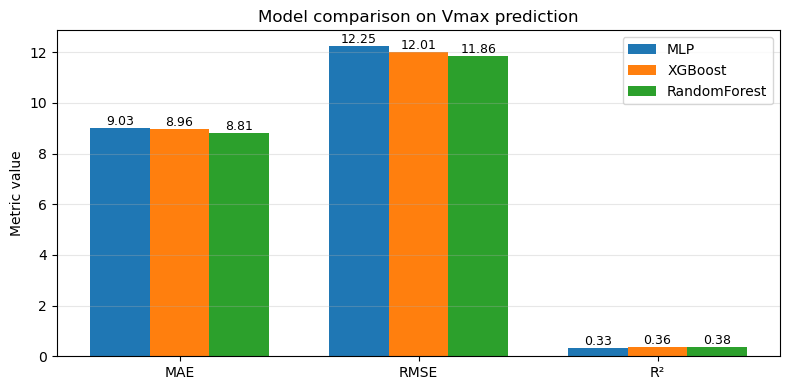

In [326]:
y_test_orig = y_test.ravel()

# MLP predictions
y_pred_mlp_s = mlp_with_shear.predict(X_test_with_shear_s)
y_pred_mlp = scaler_y.inverse_transform(
    y_pred_mlp_s.reshape(-1, 1)
).ravel()
mae_mlp = mean_absolute_error(y_test_orig, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test_orig, y_pred_mlp))
r2_mlp = r2_score(y_test_orig, y_pred_mlp)

# XGBoost predictions
y_pred_xgb = xgb_with_shear.predict(X_test_with_shear)
mae_xgb = mean_absolute_error(y_test_orig, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_orig, y_pred_xgb))
r2_xgb = r2_score(y_test_orig, y_pred_xgb)

# Random Forest predictions
y_pred_rf = rf_with_shear.predict(X_test_with_shear)
mae_rf = mean_absolute_error(y_test_orig, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_orig, y_pred_rf))
r2_rf = r2_score(y_test_orig, y_pred_rf)

print("Test metrics :")
print("MLP        -> MAE:", mae_mlp, "RMSE:", rmse_mlp, "R2:", r2_mlp)
print("XGBoost    -> MAE:", mae_xgb, "RMSE:", rmse_xgb, "R2:", r2_xgb)
print("RandomForest -> MAE:", mae_rf, "RMSE:", rmse_rf, "R2:", r2_rf)

# Barplot comparison
models = ["MLP", "XGBoost", "RandomForest"]
metrics = ["MAE", "RMSE", "R²"]

mlp_vals = [mae_mlp, rmse_mlp, r2_mlp]
xgb_vals = [mae_xgb, rmse_xgb, r2_xgb]
rf_vals = [mae_rf, rmse_rf, r2_rf]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))

bars1 = ax.bar(x - width, mlp_vals, width, label="MLP")
bars2 = ax.bar(x, xgb_vals, width, label="XGBoost")
bars3 = ax.bar(x + width, rf_vals, width, label="RandomForest")

ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylabel("Metric value")
ax.set_title("Model comparison on Vmax prediction")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# ---------- Add values above bars ----------
def add_labels(bars):
    for b in bars:
        height = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            height,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
# --------------------------------------------

plt.tight_layout()
plt.show()



In [217]:
tcva_tcprimed = pd.read_csv("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/TCVA_matched_with_SARGEO_tcprimed.csv")
df = tcva_tcprimed.copy()
shear_cols = [c for c in df.columns if c.startswith("shear_magnitude")]
target = "haversin_distance_km"
corrs = df[shear_cols + [target]].corr()[target].drop(target)

print("Correlation shear vs center difference:")
print(corrs.sort_values(ascending=False))

Correlation shear vs center difference:
shear_magnitude_5    0.178076
shear_magnitude_6    0.174245
shear_magnitude_7    0.159126
shear_magnitude_8    0.156684
shear_magnitude_2    0.131367
shear_magnitude_1    0.110825
shear_magnitude_3    0.108137
shear_magnitude_4    0.107545
Name: haversin_distance_km, dtype: float64


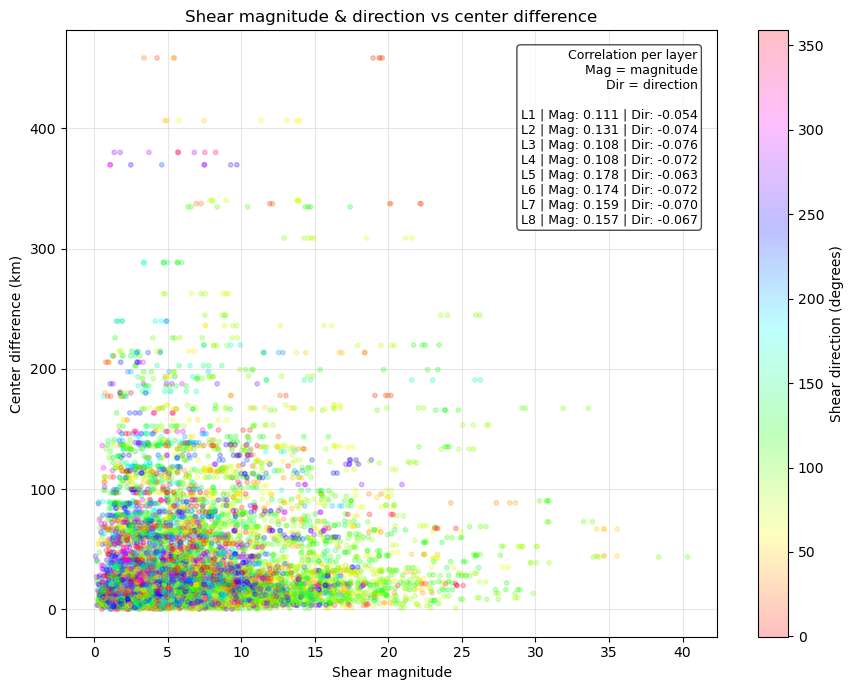

In [218]:
import numpy as np
import matplotlib.pyplot as plt

df = tcva_tcprimed.copy()
target = "haversin_distance_km"

mag_cols = [c for c in df.columns if c.startswith("shear_magnitude_")]
dir_cols = [c for c in df.columns if c.startswith("shear_direction_")]

fig, ax = plt.subplots(figsize=(9, 7))

# Scatter
for m_col, d_col in zip(mag_cols, dir_cols):
    sc = ax.scatter(
        df[m_col],
        df[target],
        c=df[d_col],
        cmap="hsv",
        alpha=0.25,
        s=10
    )

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Shear direction (degrees)")

ax.set_xlabel("Shear magnitude")
ax.set_ylabel("Center difference (km)")
ax.set_title("Shear magnitude & direction vs center difference")

# ---- correlations ----
corr_mag = df[mag_cols + [target]].corr()[target].drop(target)
corr_dir = df[dir_cols + [target]].corr()[target].drop(target)

lines = []
for i in range(len(mag_cols)):
    lines.append(
        f"L{i+1} | Mag: {corr_mag.iloc[i]:.3f} | Dir: {corr_dir.iloc[i]:.3f}"
    )

text = "Correlation per layer\nMag = magnitude\nDir = direction\n\n" + "\n".join(lines)

ax.text(
    0.97, 0.97, text,
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


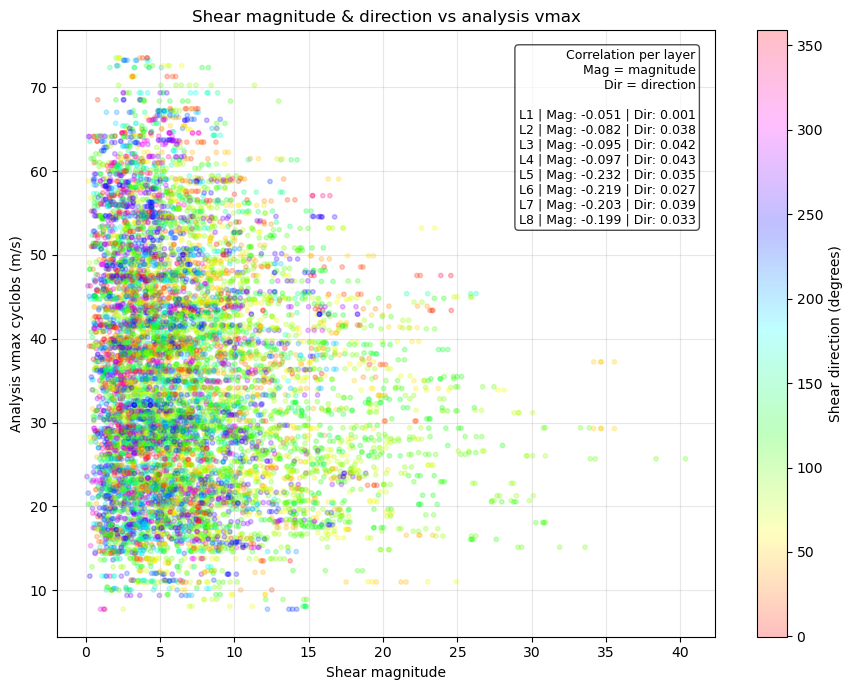

In [125]:
import numpy as np
import matplotlib.pyplot as plt

df = tcva_tcprimed.copy()
target = "analysis_vmax"

mag_cols = [c for c in df.columns if c.startswith("shear_magnitude_")]
dir_cols = [c for c in df.columns if c.startswith("shear_direction_")]

fig, ax = plt.subplots(figsize=(9, 7))

# Scatter
for m_col, d_col in zip(mag_cols, dir_cols):
    sc = ax.scatter(
        df[m_col],
        df[target],
        c=df[d_col],
        cmap="hsv",
        alpha=0.25,
        s=10
    )

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Shear direction (degrees)")

ax.set_xlabel("Shear magnitude")
ax.set_ylabel("Analysis vmax cyclobs (m/s)")
ax.set_title("Shear magnitude & direction vs analysis vmax")

# ---- correlations ----
corr_mag = df[mag_cols + [target]].corr()[target].drop(target)
corr_dir = df[dir_cols + [target]].corr()[target].drop(target)

lines = []
for i in range(len(mag_cols)):
    lines.append(
        f"L{i+1} | Mag: {corr_mag.iloc[i]:.3f} | Dir: {corr_dir.iloc[i]:.3f}"
    )

text = "Correlation per layer\nMag = magnitude\nDir = direction\n\n" + "\n".join(lines)

ax.text(
    0.97, 0.97, text,
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


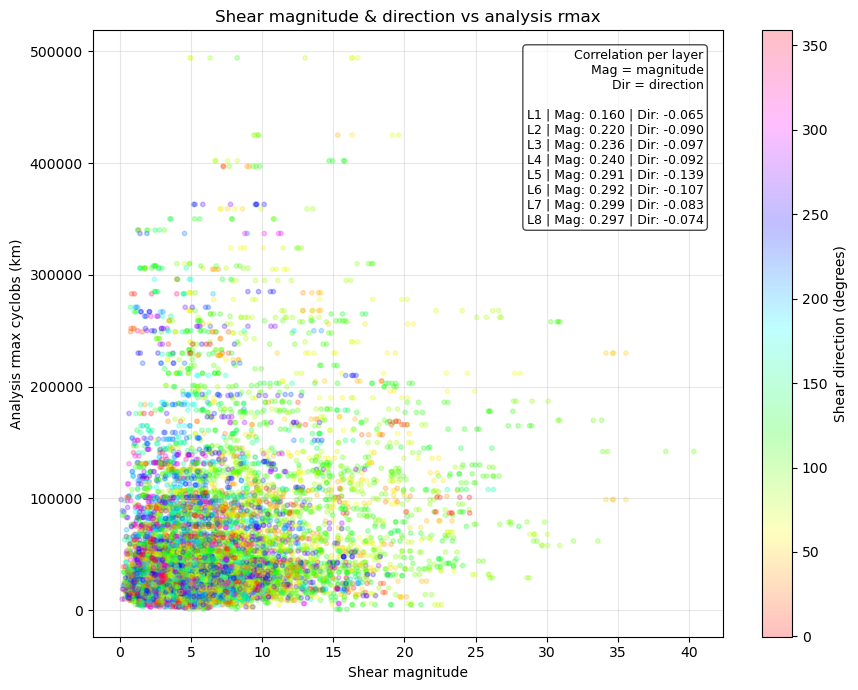

In [126]:
import numpy as np
import matplotlib.pyplot as plt

df = tcva_tcprimed.copy()
target = "analysis_rmax"

mag_cols = [c for c in df.columns if c.startswith("shear_magnitude_")]
dir_cols = [c for c in df.columns if c.startswith("shear_direction_")]

fig, ax = plt.subplots(figsize=(9, 7))

# Scatter
for m_col, d_col in zip(mag_cols, dir_cols):
    sc = ax.scatter(
        df[m_col],
        df[target],
        c=df[d_col],
        cmap="hsv",
        alpha=0.25,
        s=10
    )

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Shear direction (degrees)")

ax.set_xlabel("Shear magnitude")
ax.set_ylabel("Analysis rmax cyclobs (km)")
ax.set_title("Shear magnitude & direction vs analysis rmax")

# ---- correlations ----
corr_mag = df[mag_cols + [target]].corr()[target].drop(target)
corr_dir = df[dir_cols + [target]].corr()[target].drop(target)

lines = []
for i in range(len(mag_cols)):
    lines.append(
        f"L{i+1} | Mag: {corr_mag.iloc[i]:.3f} | Dir: {corr_dir.iloc[i]:.3f}"
    )

text = "Correlation per layer\nMag = magnitude\nDir = direction\n\n" + "\n".join(lines)

ax.text(
    0.97, 0.97, text,
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## correlation with cyclons_phase_sapce_thermal_wind

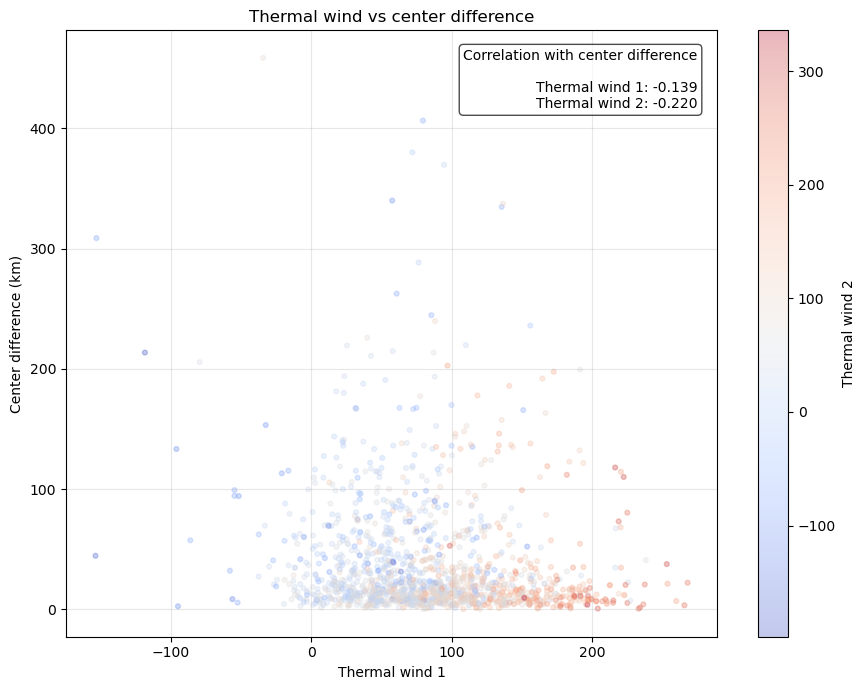

In [222]:
import matplotlib.pyplot as plt

df = tcva_tcprimed.copy()
target = "haversin_distance_km"

tw1 = "cyclone_phase_space_thermal_wind_1"
tw2 = "cyclone_phase_space_thermal_wind_2"

fig, ax = plt.subplots(figsize=(9, 7))

# scatter
sc = ax.scatter(
    df[tw1],
    df[target],
    c=df[tw2],
    cmap="coolwarm",
    alpha=0.3,
    s=12
)

# colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Thermal wind 2")

ax.set_xlabel("Thermal wind 1")
ax.set_ylabel("Center difference (km)")
ax.set_title("Thermal wind vs center difference")

# correlations
corr_tw1 = df[[tw1, target]].corr().iloc[0, 1]
corr_tw2 = df[[tw2, target]].corr().iloc[0, 1]

text = (
    "Correlation with center difference\n\n"
    f"Thermal wind 1: {corr_tw1:.3f}\n"
    f"Thermal wind 2: {corr_tw2:.3f}"
)

ax.text(
    0.97, 0.97, text,
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


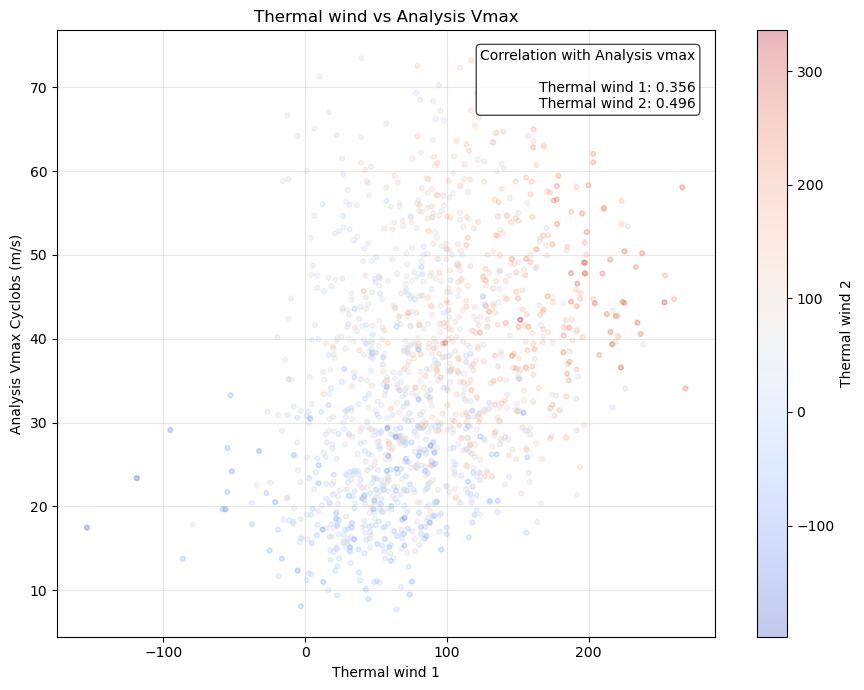

In [228]:
import matplotlib.pyplot as plt

df = tcva_tcprimed.copy()
target = "analysis_vmax"

tw1 = "cyclone_phase_space_thermal_wind_1"
tw2 = "cyclone_phase_space_thermal_wind_2"

fig, ax = plt.subplots(figsize=(9, 7))

# scatter
sc = ax.scatter(
    df[tw1],
    df[target],
    c=df[tw2],
    cmap="coolwarm",
    alpha=0.3,
    s=12
)

# colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Thermal wind 2")

ax.set_xlabel("Thermal wind 1")
ax.set_ylabel("Analysis Vmax Cyclobs (m/s)")
ax.set_title("Thermal wind vs Analysis Vmax")

# correlations
corr_tw1 = df[[tw1, target]].corr().iloc[0, 1]
corr_tw2 = df[[tw2, target]].corr().iloc[0, 1]

text = (
    "Correlation with Analysis vmax\n\n"
    f"Thermal wind 1: {corr_tw1:.3f}\n"
    f"Thermal wind 2: {corr_tw2:.3f}"
)

ax.text(
    0.97, 0.97, text,
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


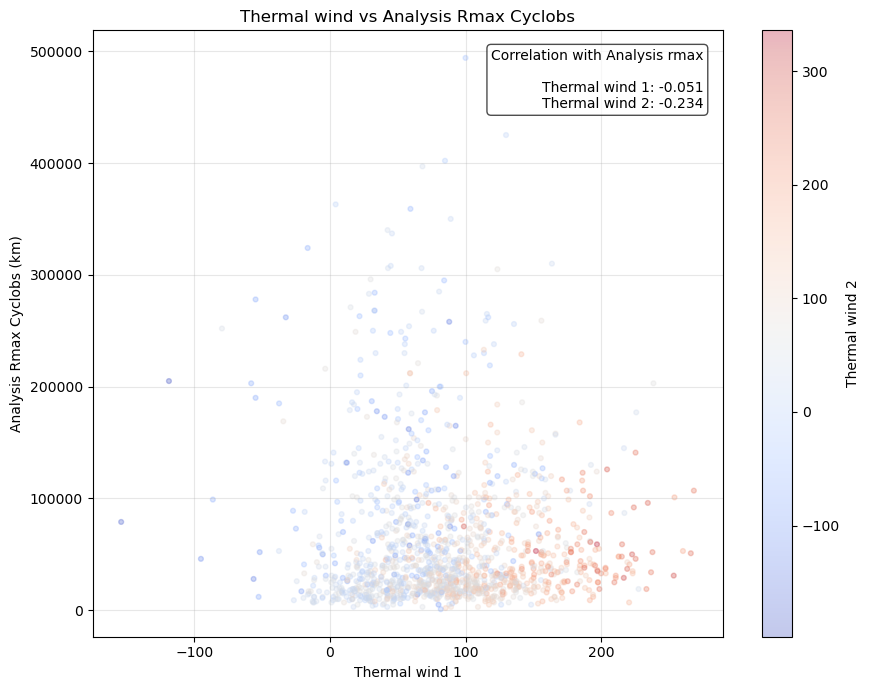

In [227]:
import matplotlib.pyplot as plt

df = tcva_tcprimed.copy()
target = "analysis_rmax"

tw1 = "cyclone_phase_space_thermal_wind_1"
tw2 = "cyclone_phase_space_thermal_wind_2"

fig, ax = plt.subplots(figsize=(9, 7))

# scatter
sc = ax.scatter(
    df[tw1],
    df[target],
    c=df[tw2],
    cmap="coolwarm",
    alpha=0.3,
    s=12
)

# colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Thermal wind 2")

ax.set_xlabel("Thermal wind 1")
ax.set_ylabel("Analysis Rmax Cyclobs (km)")
ax.set_title("Thermal wind vs Analysis Rmax Cyclobs")

# correlations
corr_tw1 = df[[tw1, target]].corr().iloc[0, 1]
corr_tw2 = df[[tw2, target]].corr().iloc[0, 1]

text = (
    "Correlation with Analysis rmax\n\n"
    f"Thermal wind 1: {corr_tw1:.3f}\n"
    f"Thermal wind 2: {corr_tw2:.3f}"
)

ax.text(
    0.97, 0.97, text,
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
